In [1]:
#Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
#Generate Your Own Banking Dataset

np.random.seed(42)

rows = 5000

data = pd.DataFrame({

    "customer_id": np.arange(1, rows+1),

    "salary": np.random.randint(25000,300000,rows),

    "bank_balance": np.random.randint(50000,5000000,rows),

    "loan_amount": np.random.randint(0,10000000,rows),

    "transaction_count": np.random.randint(10,1000,rows),

    "credit_card_spend": np.random.randint(1000,1000000,rows),

    "travel_spend": np.random.randint(0,100000,rows),

    "electricity_bill": np.random.randint(1000,52000,rows),

    "bank_profit": np.random.randint(5000,300000,rows)

})

data["carbon_emission"] = (
data["travel_spend"]*0.4 +
data["electricity_bill"]*0.6 +
data["credit_card_spend"]*0.2 +
data["transaction_count"]*0.1
)

data.to_csv("bank_carbon_dataset.csv",index=False)

data.head()

,customer_id,salary,bank_balance,loan_amount,transaction_count,credit_card_spend,travel_spend,electricity_bill,bank_profit,carbon_emission
0,1,146958,3424775,1610921,440,860701,72852,25862,131162,216842.2
1,2,171867,2240002,4463593,919,112414,2843,32103,296788,42973.7
2,3,156932,3043349,6916950,756,858017,28015,12510,41122,190391.0
3,4,284178,1292522,2694670,212,44086,69647,35691,190641,58111.8
4,5,144879,2618101,6970746,850,898369,45231,14402,240657,206492.4


In [3]:
#Carbon Score Calculation

def carbon_score(co2):

    if co2 < 5000:
        return "Low"

    elif co2 < 15000:
        return "Medium"

    else:
        return "High"


data["carbon_level"] = data["carbon_emission"].apply(carbon_score)

data.head()

,customer_id,salary,bank_balance,loan_amount,transaction_count,credit_card_spend,travel_spend,electricity_bill,bank_profit,carbon_emission,carbon_level
0,1,146958,3424775,1610921,440,860701,72852,25862,131162,216842.2,High
1,2,171867,2240002,4463593,919,112414,2843,32103,296788,42973.7,High
2,3,156932,3043349,6916950,756,858017,28015,12510,41122,190391.0,High
3,4,284178,1292522,2694670,212,44086,69647,35691,190641,58111.8,High
4,5,144879,2618101,6970746,850,898369,45231,14402,240657,206492.4,High


In [4]:
#ESG Score System

data["environment_score"] = 100 - (data["carbon_emission"] / data["carbon_emission"].max()) * 100

data["social_score"] = np.random.randint(50,100,len(data))

data["governance_score"] = np.random.randint(50,100,len(data))

data["esg_score"] = (
data["environment_score"] +
data["social_score"] +
data["governance_score"]
)/3

data.head()

,customer_id,salary,bank_balance,loan_amount,transaction_count,credit_card_spend,travel_spend,electricity_bill,bank_profit,carbon_emission,carbon_level,environment_score,social_score,governance_score,esg_score
0,1,146958,3424775,1610921,440,860701,72852,25862,131162,216842.2,High,18.242233,68,61,49.080744
1,2,171867,2240002,4463593,919,112414,2843,32103,296788,42973.7,High,83.797279,65,73,73.932426
2,3,156932,3043349,6916950,756,858017,28015,12510,41122,190391.0,High,28.215343,54,89,57.071781
3,4,284178,1292522,2694670,212,44086,69647,35691,190641,58111.8,High,78.089639,76,80,78.029880
4,5,144879,2618101,6970746,850,898369,45231,14402,240657,206492.4,High,22.144502,93,50,55.048167


In [5]:
#Train ML Model

X = data.drop(["customer_id","carbon_emission","carbon_level"],axis=1)

y = data["carbon_emission"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

print("Model Error:",mean_absolute_error(y_test,predictions))

Model Error: 46.872884999998206


In [6]:
#Carbon Prediction for New Customer

customer = [[
50000,
100000,
200000,
150,
20000,
10000,
1500,
5000,
70,
80,
75,
75
]]

prediction = model.predict(customer)

print("Predicted Carbon Emission:",prediction)

Predicted Carbon Emission: [79603.112]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [7]:
#Green Loan Recommendation System

def green_loan_recommendation(carbon):

    if carbon > 15000:
        return "Recommend Solar Loan"

    elif carbon > 8000:
        return "Recommend EV Loan"

    else:
        return "Customer already low carbon"


print(green_loan_recommendation(prediction[0]))

Recommend Solar Loan


In [7]:
#GenAI Sustainability Report Generator

def generate_report(customer_id, carbon, esg):

    report = f"""
Customer ID: {customer_id}

Carbon Emission: {carbon}

ESG Score: {esg}

AI Sustainability Analysis:

This customer has a carbon footprint influenced by travel
spending and electricity consumption.

Recommendation:
Encourage green banking products like solar energy loans,
EV loans, and sustainable investment plans.
"""

    return report


print(generate_report(101,prediction[0],75))


Customer ID: 101

Carbon Emission: 79603.11199999988

ESG Score: 75

AI Sustainability Analysis:

This customer has a carbon footprint influenced by travel
spending and electricity consumption.

Recommendation:
Encourage green banking products like solar energy loans,
EV loans, and sustainable investment plans.



In [8]:
#AI Carbon Chatbot

def carbon_chatbot(question):

    if "high carbon" in question.lower():

        result = data.sort_values("carbon_emission",ascending=False).head()

        return result

    elif "low carbon" in question.lower():

        result = data.sort_values("carbon_emission").head()

        return result

    elif "average carbon" in question.lower():

        return data["carbon_emission"].mean()

    else:

        return "Ask about carbon emissions."


carbon_chatbot("high carbon customers")

,customer_id,salary,bank_balance,loan_amount,transaction_count,credit_card_spend,travel_spend,electricity_bill,bank_profit,carbon_emission,carbon_level,environment_score,social_score,governance_score,esg_score
2354,2355,129648,721253,1390688,692,991506,89998,51426,34236,265225.2,High,0.000000,94,53,49.000000
2840,2841,263038,849288,7190953,536,989633,95390,43683,60237,262346.0,High,1.085568,91,99,63.695189
497,498,239532,349189,5402066,657,963798,99056,47390,82510,260881.7,High,1.637665,81,51,44.545888
4996,4997,129186,1622102,5443157,142,993309,98919,35818,198982,259734.4,High,2.070241,61,72,45.023414
4715,4716,257069,513723,5865522,790,983453,89567,44808,258902,259481.2,High,2.165707,51,89,47.388569


In [ ]:
#CUSTOMER SUPPORT CHATBOT


def bank_chatbot(question):

    question = question.lower()

    if "loan" in question:
        return "Our bank offers personal loan, home loan, EV loan, and solar energy loan."

    elif "carbon" in question:
        return "Carbon footprint is calculated from travel spending, electricity usage, and transactions."

    elif "reduce carbon" in question:
        return "You can reduce carbon by using green energy, electric vehicles, and sustainable banking services."

    elif "esg" in question:
        return "ESG means Environmental, Social, and Governance sustainability score."

    elif "green loan" in question:
        return "We provide Solar Loans, Electric Vehicle Loans, and Green Home Loans."

    elif "balance" in question:
        return "Please login to the secure bank dashboard to view account balance."

    elif "high carbon" in question:
        return data.sort_values("carbon_emission",ascending=False).head()

    elif "low carbon" in question:
        return data.sort_values("carbon_emission").head()

    else:
        return "Please ask about loans, ESG score, carbon footprint, or green banking."

print("\nBank AI Assistant Ready (type 'exit' to stop)\n")

while True:

    user = input("Customer: ")

    if user.lower() == "exit":
        print("Bank AI: Thank you for using our AI Banking Assistant.")
        break

    response = bank_chatbot(user)

    print("Bank AI:",response)


Bank AI Assistant Ready (type 'exit' to stop)



Customer:  solar


Bank AI: Please ask about loans, ESG score, carbon footprint, or green banking.


Customer:  egs


Bank AI: Please ask about loans, ESG score, carbon footprint, or green banking.


Customer:  green


Bank AI: Please ask about loans, ESG score, carbon footprint, or green banking.


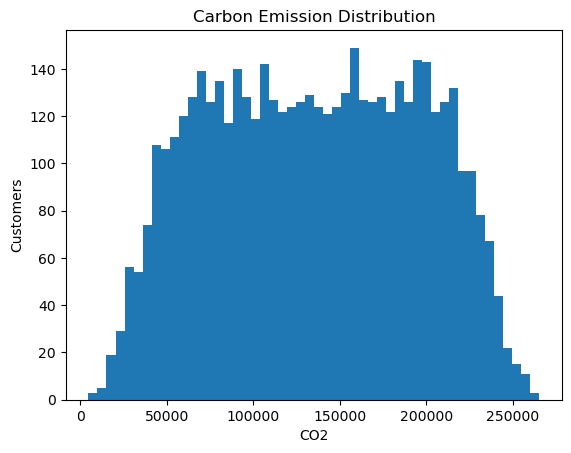

In [10]:
#Data Visualization

plt.hist(data["carbon_emission"],bins=50)

plt.title("Carbon Emission Distribution")

plt.xlabel("CO2")

plt.ylabel("Customers")

plt.show()